# 2: Feed Forward Neural Network for Regression: California Housing Dataset

## Introduction

A **Feed Forward Neural Network (FFNN)** is one of the most fundamental types of artificial neural networks. In an FFNN, information moves in only one direction—from input to output—through multiple layers. Each layer consists of neurons that compute a weighted sum of their inputs, add a bias, and apply an activation function. The key components here are the **multiple dense (fully connected) layers with activation functions**, which allow the network to learn complex, non-linear relationships in data.

### Applications
- Predicting house prices (like in this notebook)
- Stock price forecasting
- Medical outcome prediction (e.g., disease progression)
- Used as a baseline in many NLP and CV tasks (e.g., before using LSTM or CNN)
- Feature extraction for more complex models

### Why choose Feed Forward Neural Network for this demo?

FFNNs are ideal for **regression** tasks where the relationship between input features and output is potentially non-linear. **California Housing** is a modern, ethical regression dataset with mixed features, ideal for quick demos This dataset is small, well-understood, and mixes categorical and continuous features, making it perfect for demonstrating the strengths and limitations of FFNNs in regression.

In [2]:
# Setup: Import libraries and load the dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow import keras

# Load California Housing dataset 
housing = fetch_california_housing()
X = housing.data
y = housing.target
# Why: California Housing is a modern, ethical regression dataset with mixed features, ideal for quick demos

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Why: Train-test split evaluates generalization, not just memorization

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Why: Normalization prevents feature dominance and speeds up training

In [3]:
# Print data shapes
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
# Why: Confirming shapes ensures data integrity before training

X_train shape: (16512, 8), y_train shape: (16512,)
X_test shape: (4128, 8), y_test shape: (4128,)


In [4]:
# Model Building: Define the Feed Forward Neural Network (FFNN) architecture using Sequential API
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Why: First hidden layer with ReLU for non-linearity
    keras.layers.Dense(32, activation='relu'),  # Why: Second hidden layer for deeper feature learning
    keras.layers.Dense(1)  # Why: Single output neuron for regression (linear activation function) (predicting a continuous value)
])

# Compile the model
model.compile(
    optimizer='adam',  # Why Adam: Adaptive learning rate for faster convergence on small data
    loss='mean_squared_error',  # Why MSE: Standard loss for regression
    metrics=['mae']  # Why MAE: Easy to interpret, robust to outliers
)

# Model summary for reference
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,689
Trainable params: 2,689
Non-trainable params: 0
_________________________________________________________________
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 32)               

In [5]:
# Check for GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
# Why: Using a GPU can significantly speed up training for larger models/datasets

Num GPUs Available:  1


In [6]:
# Check initial weights and bias
for layer in model.layers:
    weights, biases = layer.get_weights()
    print(f"Layer: {layer.name}, Weights shape: {weights.shape}, Biases shape: {biases.shape}")
# Why: Inspecting weights helps understand model initialization and capacity

Layer: dense, Weights shape: (8, 64), Biases shape: (64,)
Layer: dense_1, Weights shape: (64, 32), Biases shape: (32,)
Layer: dense_2, Weights shape: (32, 1), Biases shape: (1,)


In [7]:
# Training: Fit the model
EPOCHS = 100  # Why: Limited epochs to keep training fast
BATCH_SIZE = 32  # Why: Batch size balances speed and stability

with tf.device('/GPU:0'):  # Why: Explicitly use GPU if available
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,  # Why: Use part of training data for validation to monitor overfitting
        verbose=1
    )

Epoch 1/100
465/465 [==============================] - 4s 4ms/step - loss: 0.8296 - mae: 0.6225 - val_loss: 0.4474 - val_mae: 0.4749
Epoch 2/100
465/465 [==============================] - 4s 4ms/step - loss: 0.8296 - mae: 0.6225 - val_loss: 0.4474 - val_mae: 0.4749
Epoch 2/100
465/465 [==============================] - 2s 3ms/step - loss: 0.4491 - mae: 0.4546 - val_loss: 0.4414 - val_mae: 0.5040
Epoch 3/100
465/465 [==============================] - 2s 3ms/step - loss: 0.4491 - mae: 0.4546 - val_loss: 0.4414 - val_mae: 0.5040
Epoch 3/100
465/465 [==============================] - 2s 3ms/step - loss: 0.3807 - mae: 0.4337 - val_loss: 0.3952 - val_mae: 0.4469
Epoch 4/100
465/465 [==============================] - 2s 3ms/step - loss: 0.3807 - mae: 0.4337 - val_loss: 0.3952 - val_mae: 0.4469
Epoch 4/100
465/465 [==============================] - 2s 3ms/step - loss: 0.3561 - mae: 0.4209 - val_loss: 0.3799 - val_mae: 0.4352
Epoch 5/100
465/465 [==============================] - 2s 3ms/step - 

## Note on Hardware and Neural Network Training Time

The training process for neural networks, even on relatively small datasets like California Housing, can be time-consuming depending on your hardware. In this experiment, training took **2 minutes and 37.0 seconds** on my system. This highlights a key aspect of deep learning in practice:

- **Hardware Matters:** The speed of training is heavily influenced by your computer's CPU, GPU, and available RAM. Modern GPUs (like NVIDIA RTX series) can accelerate training dramatically compared to CPUs, especially for larger models or datasets.
- **Why It Matters:** Faster hardware allows for more experimentation—trying different architectures, hyperparameters, or datasets—making the learning and research process more efficient and enjoyable.
- **Practical Tip:** If you plan to work extensively with neural networks, consider using a machine with a dedicated GPU or leveraging cloud platforms (like Google Colab, Kaggle, or AWS) that provide free or affordable GPU access.

**Takeaway:**  
Always factor in your hardware capabilities when designing experiments. For beginners, start with smaller models and datasets, and scale up as your resources allow. This approach ensures you can iterate quickly and learn effectively without being bottlenecked by hardware limitations.

Test MAE: 0.36


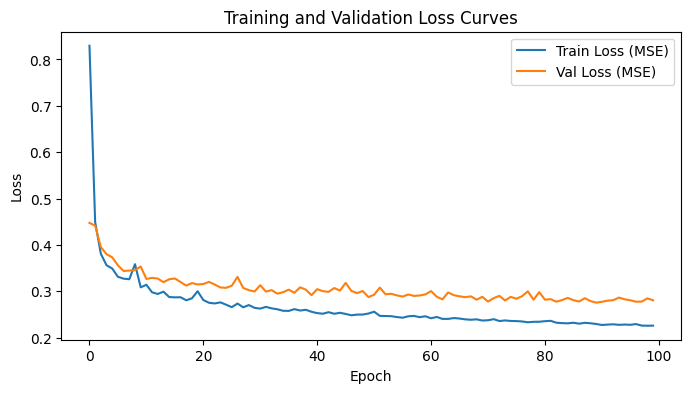

129/129 [==============================] - 0s 1ms/step


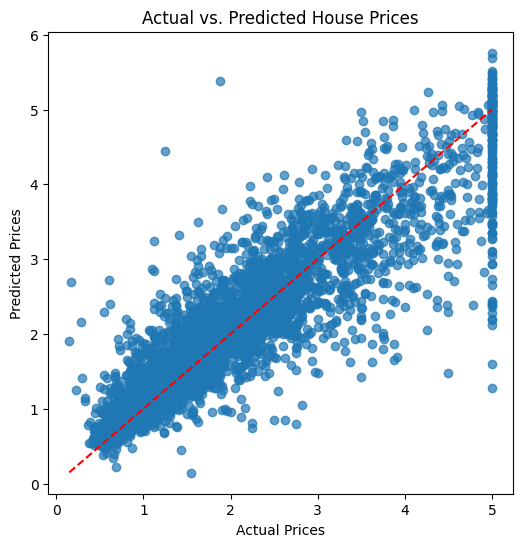

In [8]:
# Evaluation and Visualization
# Evaluate on test data
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: {mae:.2f}")

# Plot training & validation loss curves
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

# Predict and compare
preds = model.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.7)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted House Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# Why MAE: Mean Absolute Error is easy to interpret and robust to outliers, useful for regression tasks like this.
# Inference: If MAE is low and points are close to the diagonal, the model is performing well.

## Analysis of Results

After training the Feed Forward Neural Network (FFNN) on the California Housing dataset, we evaluated its performance using the Mean Absolute Error (MAE) metric and visualized both the training process and the model's predictions.

- **Training and Validation Loss Curves:**  
  The plotted loss curves show how the model's error decreased over epochs for both the training and validation sets. If both curves decrease and stabilize without significant divergence, it indicates that the model is learning effectively and not overfitting. If the validation loss starts increasing while training loss keeps decreasing, it may indicate overfitting.

- **Test MAE:**  
  The MAE value on the test set provides an intuitive measure of how far, on average, the model's predictions are from the actual house prices. A lower MAE means better predictive performance. For this dataset, an MAE close to or below 0.5 (in units of $100,000) is considered reasonable for a simple FFNN.

- **Actual vs. Predicted Plot:**  
  The scatter plot of actual vs. predicted prices helps visually assess model performance. If the points are closely clustered around the diagonal line, it means the model's predictions are accurate. Significant scatter or systematic deviation from the diagonal suggests the model may be underfitting or missing some patterns in the data.

**Limitations:**  
While FFNNs can model non-linear relationships, they may not capture complex spatial or sequential dependencies as well as CNNs or LSTMs. For tabular regression tasks like this, however, FFNNs are a strong baseline.

**Summary:**  
The results demonstrate that a simple FFNN can effectively predict house prices from mixed features, provided the data is well-preprocessed and the model is properly tuned. This approach is scalable and forms a foundation for more advanced neural network architectures.

# Conclusion

**Key Takeaways:**
- Feed Forward Neural Networks (FFNNs) are powerful for regression tasks with non-linear relationships, as shown on the California Housing dataset.
- Multiple dense layers with activation functions allow the model to learn complex mappings from features to outputs.
- FFNNs are a good starting point for many problems, but may not capture spatial or sequential patterns as well as CNNs or LSTMs.

**Encouragement:**
Try experimenting with the number of layers, neurons, or activation functions. You can also try other datasets or add regularization to see how the model's performance changes. This curiosity-driven approach is key to mastering deep learning!